# Xây dựng Kiến trúc MetaBlock Fusion (Gated Attention)

- **Bản chất**: Dữ liệu Tuổi/Vị trí không cộng dồn nữa, mà kích hoạt một lớp Màng lọc `Sigmoid Gate`, làm tăng/giảm sự chi tiết của Dữ liệu Ảnh.
- **Interpretability**: Lấy được số liệu Cổng Gate Attention để biết được Dữ liệu Bảng đóng góp bao nhiêu vào Bức ảnh.

In [7]:
import sys; sys.path.append('..')
import torch
import torch.nn as nn
import torch.nn.functional as F
from _shared_fusion_env import get_dataloaders, get_device
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Thu viện Grad-CAM XAI
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = get_device()
train_loader, test_loader, weights, tab_dim = get_dataloaders(batch_size=32)
weights = weights.to(device)
print(f"Device: {device} | Tabular Dim: {tab_dim}")

Device: mps | Tabular Dim: 58


In [8]:
class MetaBlockFusionModel(nn.Module):
    def __init__(self, tab_dim, num_classes=6):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.img_net = nn.Sequential(*list(resnet.children())[:-1])
        
        # Đưa bảng và ảnh về cùng 1 dải không gian Vector 512 chiều để MetaBlock dễ bề mổ xẻ
        self.tab_proj = nn.Sequential(
            nn.Linear(tab_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512)
        )
        self.img_proj = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )
        
        # MetaBlock (Gated Attention) chiếu ánh sáng Sigmoid 
        # Kết hợp Bảng + Ảnh => Sinh ra 1 mảng Gating 512 chiều 
        self.attention_gate = nn.Sequential(
            nn.Linear(512 + 512, 512),
            nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, img, tab, return_gate=False):
        f_img_raw = self.img_net(img)
        f_img_raw = torch.flatten(f_img_raw, 1)
        
        f_img = self.img_proj(f_img_raw)
        f_tab = self.tab_proj(tab)
        
        # Rắp thành một bó Cảm biến Attention
        combined = torch.cat([f_img, f_tab], dim=1)
        gate = self.attention_gate(combined) # Dải số từ 0 -> 1
        
        # Nơi nào gate ~ 1 => Cho phép dữ kiện Hình ảnh đi qua
        # Nơi nào gate ~ 0 => Cho phép dữ kiện y tế (Tuổi/vị trí) đi qua thay thế
        fused = gate * f_img + (1.0 - gate) * f_tab
        
        out = self.classifier(fused)
        if return_gate:
            return out, gate
        return out

=== Phase 1: Attention Module Training ===


/Users/hhh/workspace/School/PBL7/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/122 [00:06<?, ?it/s]

Epoch 1/10 | Train Loss: 1.8553


  0%|          | 0/122 [00:00<?, ?it/s]

...

Epoch 33/70 | Train Loss: 0.2106 | Val BCC: 58.44% | LR: 1.00e-06


  0%|          | 0/122 [00:00<?, ?it/s]

Epoch 34/70 | Train Loss: 0.2140 | Val BCC: 59.82% | LR: 1.00e-06


  0%|          | 0/122 [00:00<?, ?it/s]

Epoch 35/70 | Train Loss: 0.1977 | Val BCC: 58.40% | LR: 1.00e-06
   --> [-] Early Stopping kích hoạt sau 10 vòng dậm chân! Khôi phục tự động mô hình tốt nhất...


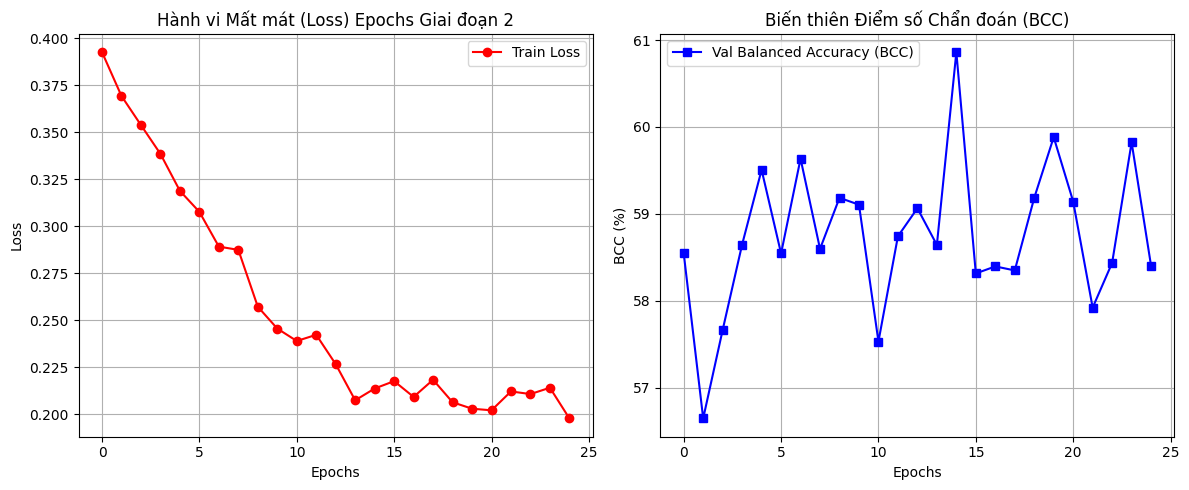

In [9]:
model = MetaBlockFusionModel(tab_dim).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

E1, E2 = 10, 60
# Giai đoạn 1: Khóa 80% xương sống ResNet
for param in model.img_net.parameters(): param.requires_grad = False
opt1 = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, momentum=0.9, weight_decay=1e-3)

print("=== Phase 1: Attention Module Training ===")
for ep in range(E1):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt1.zero_grad()
        out = model(imgs, tabs)
        loss = criterion(out, lbls) 
        loss.backward()
        opt1.step()
        running_loss += loss.item()
    print(f"Epoch {ep+1}/{E1} | Train Loss: {running_loss/len(train_loader):.4f}")

for param in model.parameters(): param.requires_grad = True
opt2 = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-3)
scheduler2 = ReduceLROnPlateau(opt2, mode='max', patience=5, factor=0.1, min_lr=1e-6)

print("\n=== Phase 2: End-to-end Fine-tuning w/ Early Stopping ===")
history_loss = []
history_bcc = []
best_bcc = 0.0
patience = 10
stagnant = 0
import os
os.makedirs('../../saved_models', exist_ok=True)
best_model_path = '../../saved_models/metablock_best_auto.pth'

for ep in range(E2):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt2.zero_grad()
        out = model(imgs, tabs)
        loss = criterion(out, lbls)
        loss.backward()
        opt2.step()
        running_loss += loss.item()
    
    # --- EVALUATION LOOP ---
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, tabs, lbls in test_loader:
            out = model(imgs.to(device), tabs.to(device))
            _, y_hat = torch.max(out, 1)
            preds.extend(y_hat.cpu().numpy())
            trues.extend(lbls.numpy())
            
    val_bcc = balanced_accuracy_score(trues, preds)
    scheduler2.step(val_bcc)
    history_loss.append(running_loss/len(train_loader))
    history_bcc.append(val_bcc)
    print(f"Epoch {ep+E1+1}/{E1+E2} | Train Loss: {running_loss/len(train_loader):.4f} | Val BCC: {val_bcc*100:.2f}% | LR: {opt2.param_groups[0]['lr']:.2e}")
    
    if val_bcc > best_bcc:
        best_bcc = val_bcc
        stagnant = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"   --> [+] Đỉnh cao mới BCC: {val_bcc*100:.2f}%! Đã lưu Checkpoint an toàn.")
    else:
        stagnant += 1
        if stagnant >= patience:
            print(f"   --> [-] Early Stopping kích hoạt sau {patience} vòng dậm chân! Khôi phục tự động mô hình tốt nhất...")
            model.load_state_dict(torch.load(best_model_path))
            break
# ---- VẼ BIỂU ĐỒ ĐỘNG LỰC HỌC (LEARNING CURVE) ----
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_loss, label='Train Loss', color='red', marker='o')
plt.title('Hành vi Mất mát (Loss) Epochs Giai đoạn 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot([b * 100 for b in history_bcc], label='Val Balanced Accuracy (BCC)', color='blue', marker='s')
plt.title('Biến thiên Điểm số Chẩn đoán (BCC)')
plt.xlabel('Epochs')
plt.ylabel('BCC (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Khả năng Giải thích XAI: Tham số Attention Gate 
Xuất thông số cường độ hoạt động của Sigmoid Gate.

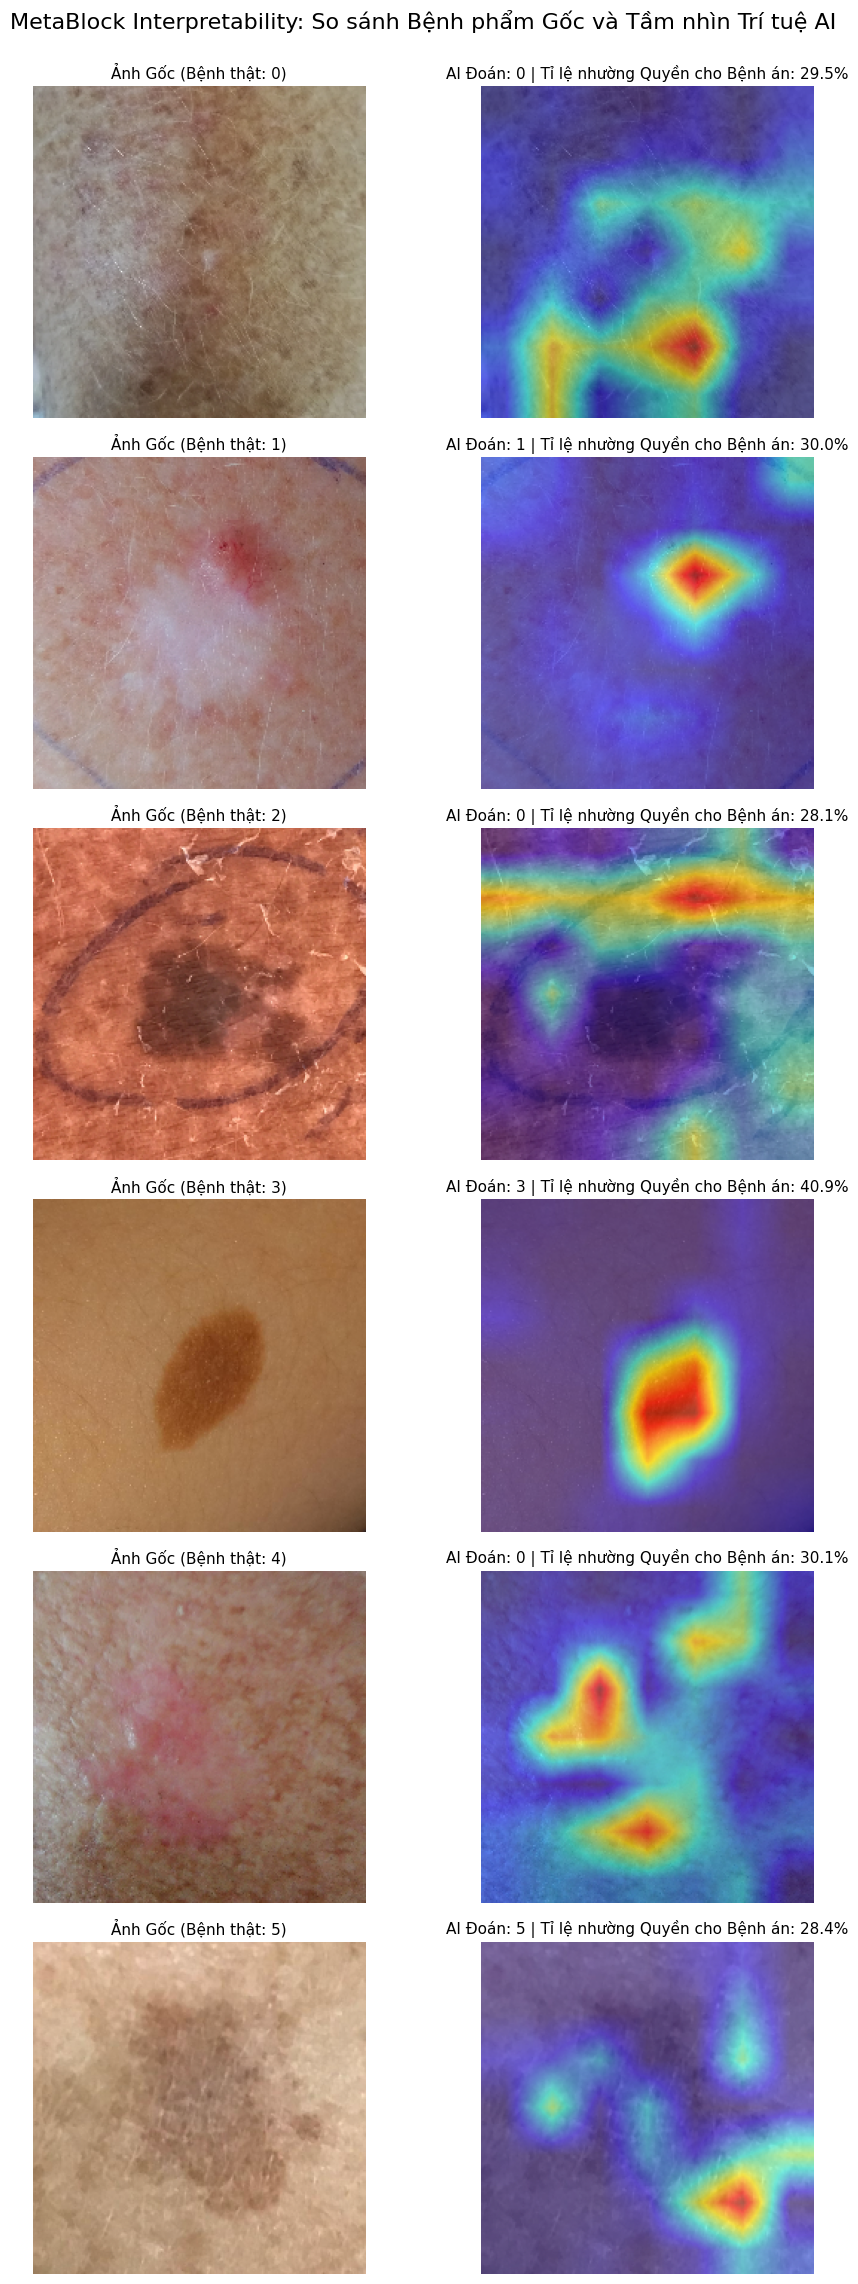

In [10]:
class ModelCAMWrapper(nn.Module):
    def __init__(self, model, fixed_tab):
        super().__init__()
        self.model = model
        self.fixed_tab = fixed_tab
    def forward(self, img):
        return self.model(img, self.fixed_tab, return_gate=False)

model.eval()

# Tìm đủ 6 ảnh mang 6 nhãn bệnh khác nhau để Demo (Từ 0 đến 5)
found_classes = set()
selected_imgs = []
selected_tabs = []
selected_lbls = []

for batch_imgs, batch_tabs, batch_lbls in test_loader:
    for i in range(len(batch_lbls)):
        c = batch_lbls[i].item()
        if c not in found_classes:
            found_classes.add(c)
            selected_imgs.append(batch_imgs[i])
            selected_tabs.append(batch_tabs[i])
            selected_lbls.append(c)
        if len(found_classes) == 6:
            break
    if len(found_classes) == 6:
        break

# Sắp xếp lại danh sách từ Nhãn 0 đến Nhãn 5 cho ngăn nắp
sorted_indices = np.argsort(selected_lbls)
selected_imgs = [selected_imgs[idx] for idx in sorted_indices]
selected_tabs = [selected_tabs[idx] for idx in sorted_indices]
selected_lbls = [selected_lbls[idx] for idx in sorted_indices]

target_layer = [model.img_net[-2][-1]]

fig, axes = plt.subplots(6, 2, figsize=(10, 24))

for i in range(6):
    img_tensor = selected_imgs[i].unsqueeze(0).to(device)
    tab_tensor = selected_tabs[i].unsqueeze(0).to(device)
    wrap_model = ModelCAMWrapper(model, tab_tensor)
    
    # Rút Bản đồ nhiệt
    cam = GradCAM(model=wrap_model, target_layers=target_layer)
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0, :]
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    rgb_img = img_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    rgb_img = np.clip(std * rgb_img + mean, 0, 1)
    
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    # Rút Trọng số Mở Cổng Tự Kỷ (Gate values)
    out, gate_val = model(img_tensor, tab_tensor, return_gate=True)
    mean_gate = gate_val.mean().item() 
    
    pred_val = torch.argmax(out).item()
    true_val = selected_lbls[i]
    
    # Ô 1: Ảnh Gốc
    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"Ảnh Gốc (Bệnh thật: {true_val})", fontsize=11)
    axes[i, 0].axis('off')
    
    # Ô 2: Bản Đồ Nhiệt
    axes[i, 1].imshow(visualization)
    axes[i, 1].set_title(f"AI Đoán: {pred_val} | Tỉ lệ nhường Quyền cho Bệnh án: {(1.0 - mean_gate)*100:.1f}%", fontsize=11)
    axes[i, 1].axis('off')

plt.suptitle("MetaBlock Interpretability: So sánh Bệnh phẩm Gốc và Tầm nhìn Trí tuệ AI", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

  0%|          | 0/15 [00:00<?, ?it/s]


MetaBlock Fusion F1-Macro Score: 0.6038


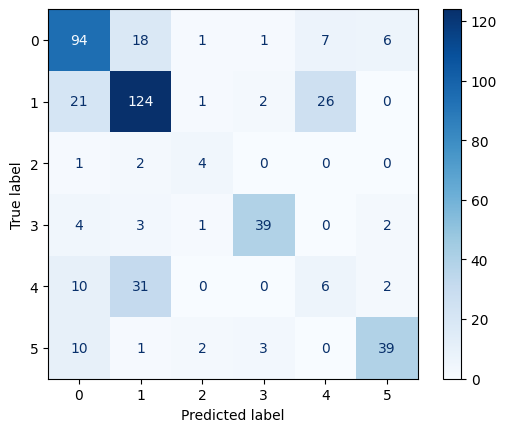

In [11]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for imgs, tabs, lbls in tqdm(test_loader):
        out = model(imgs.to(device), tabs.to(device))
        _, y_hat = torch.max(out, 1)
        preds.extend(y_hat.cpu().numpy())
        trues.extend(lbls.numpy())

f1 = f1_score(trues, preds, average='macro')
print(f"\nMetaBlock Fusion F1-Macro Score: {f1:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix(trues, preds))
disp.plot(cmap='Blues')
plt.show()

## Lưu Mô hình (Model Checkpoint)
Bảo toàn Trọng số học được (Weights) để phục vụ cho Test độc lập hoặc Triển khai Web App/Mobile sau này mà không cần Train lại.

In [12]:
import os
os.makedirs('../../saved_models', exist_ok=True)
save_path = '../../saved_models/metablock_fusion.pth'
torch.save(model.state_dict(), save_path)
print(f"✅ Đã lưu trọng số mô hình tại: {save_path}")

✅ Đã lưu trọng số mô hình tại: ../../saved_models/metablock_fusion.pth
